In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os

# CANSWE Data

In [2]:
cs = xr.open_dataset("CanSWE-CanEEN_1928-2025_v8.nc", engine="netcdf4")
cs

<xarray.Dataset> Size: 2GB
Dimensions:           (station_id: 2963, time: 35642)
Coordinates:
  * station_id        (station_id) <U25 296kB 'ALE-05AA805' ... 'RTA-CQCS'
  * time              (time) datetime64[ns] 285kB 1928-01-01 ... 2025-07-31
Data variables: (12/17)
    lat               (station_id) float32 12kB ...
    lon               (station_id) float32 12kB ...
    elevation         (station_id) float32 12kB ...
    source            (station_id) <U54 640kB ...
    station_name      (station_id) <U50 593kB ...
    station_name_sec  (station_id) <U25 296kB ...
    ...                ...
    snd               (station_id, time) float32 422MB ...
    den               (station_id, time) float32 422MB ...
    data_flag_snw     (station_id, time) |S1 106MB ...
    data_flag_snd     (station_id, time) |S1 106MB ...
    qc_flag_snw       (station_id, time) |S1 106MB ...
    qc_flag_snd       (station_id, time) |S1 106MB ...
Attributes:
    Conventions:     CF-1.9
    title:           Canadian historical Snow Water Equivalent database - CanSWE
    source:          Manual snow surveys, automatic snow pillows and automati...
    comment:         See Vionnet et al. (ESSD, 2021) for a description of the...
    latest_update:   12 March 2026
    redistribution:  CanSWE is distributed under the Open Government Licence ...

Looking just at data in my permafrost range

In [10]:
lat_mask = (cs["lat"] >= 62) & (cs["lat"] <= 69)
time_mask = (  '2001-01-01 07:30:00+00:00')
cs_filtered = cs.sel(station_id=lat_mask)
cs_filtered = cs_filtered.sel(time=slice("1995-01-01", "2014-12-31"))

print(f"Original stations: {cs.dims['station_id']}")
print(f"Filtered stations: {cs_filtered.dims['station_id']}")
cs_filtered

Original stations: 2963
Filtered stations: 122


C:\Users\madel\AppData\Local\Temp\ipykernel_18496\3738401340.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Original stations: {cs.dims['station_id']}")
C:\Users\madel\AppData\Local\Temp\ipykernel_18496\3738401340.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Filtered stations: {cs_filtered.dims['station_id']}")


<xarray.Dataset> Size: 14MB
Dimensions:           (station_id: 122, time: 7305)
Coordinates:
  * station_id        (station_id) <U25 12kB 'INA-07PA02' ... 'NWT-10LC-SC02'
  * time              (time) datetime64[ns] 58kB 1995-01-01 ... 2014-12-31
Data variables: (12/17)
    lat               (station_id) float32 488B 65.2 62.72 62.33 ... 67.23 67.63
    lon               (station_id) float32 488B ...
    elevation         (station_id) float32 488B ...
    source            (station_id) <U54 26kB ...
    station_name      (station_id) <U50 24kB ...
    station_name_sec  (station_id) <U25 12kB ...
    ...                ...
    snd               (station_id, time) float32 4MB ...
    den               (station_id, time) float32 4MB ...
    data_flag_snw     (station_id, time) |S1 891kB ...
    data_flag_snd     (station_id, time) |S1 891kB ...
    qc_flag_snw       (station_id, time) |S1 891kB ...
    qc_flag_snd       (station_id, time) |S1 891kB ...
Attributes:
    Conventions:     CF-1.9
    title:           Canadian historical Snow Water Equivalent database - CanSWE
    source:          Manual snow surveys, automatic snow pillows and automati...
    comment:         See Vionnet et al. (ESSD, 2021) for a description of the...
    latest_update:   12 March 2026
    redistribution:  CanSWE is distributed under the Open Government Licence ...

In [8]:
df = pd.DataFrame({
    "station_id": cs_filtered["station_id"].values,
    "lat":        cs_filtered["lat"].values,
    "lon":        cs_filtered["lon"].values,
})

df.to_csv("stations_62_69.txt", index=False, sep="\t")
print(f"Saved {len(df)} stations to stations_62_69.txt")

Saved 122 stations to stations_62_69.txt


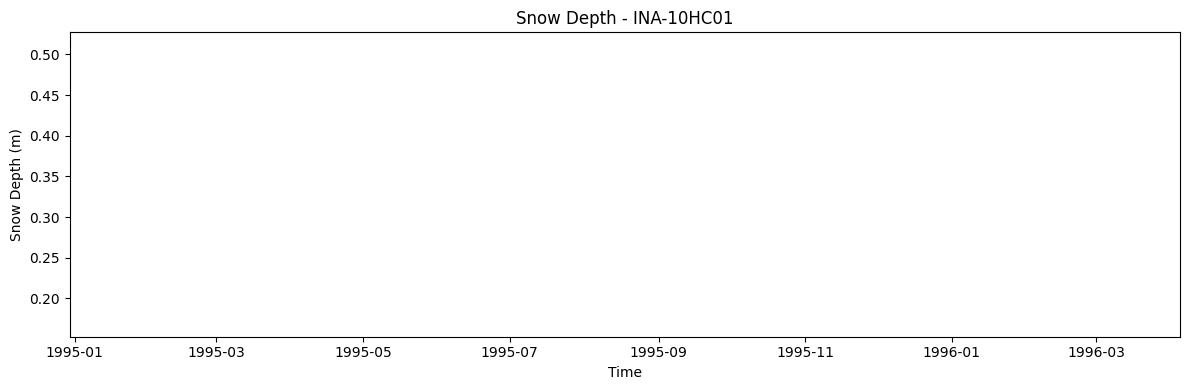

In [18]:
site = "INA-10HC01"  # change to your desired station_id

snow = cs_filtered.sel(station_id=site)["snd"]

plt.figure(figsize=(12, 4))
plt.plot(snow["time"], snow.values)
plt.title(f"Snow Depth - {site}")
plt.xlabel("Time")
plt.ylabel("Snow Depth (m)")
plt.tight_layout()
plt.savefig(f"snowdepth_{site}.png", dpi=150)
plt.show()

## Loading in model data

In [2]:
df = xr.open_dataset("TVC_1995-2014.nc", engine="netcdf4")
var_snowd = df["SNOW_DEPTH"]
var_snowd

/tmp/ipykernel_127332/767066768.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset("TVC_1995-2014.nc", engine="netcdf4")


<xarray.DataArray 'SNOW_DEPTH' (time: 7300, lndgrid: 1)> Size: 29kB
[7300 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      snow height of snow covered area
    units:          m
    cell_methods:   time: mean
    landunit_mask:  unknown

## Observational Plots

NOTE: Currently files need to be in opposite time order from top to bottom for the combination code to work. This is because sorting by datetime in pandas is being weird and i dont wana figure it out rn

In [3]:
def obs_data_parse(file):
    obs = pd.read_csv(
    f"{file}",   # just change the extension
    comment="#",
    sep=r"\s+|,|\t",
    parse_dates=["Timestamp"],
    engine="python"
    )
    obs.rename(columns={"Timestamp": "time", "Value": "obs_depth"}, inplace=True)
    return obs

In [4]:
# Input ypur path to all observational values
# Makes a simple list for now but could definitely be a dictionary later
directory_path = "TVC_obs/snow_depth"
observe = {}

for filename in os.listdir(directory_path):
    # Join the directory path and the filename to get the full file path
    full_path = os.path.join(directory_path, filename)
    # Check if it is a file (not a directory)
    if os.path.isfile(full_path):
        df = obs_data_parse(full_path)
        observe.update({f"{filename}":df})


In [5]:
for x in observe:
  print(observe[x]) 

                           time  obs_depth
0     2002-01-01 07:30:00+00:00      258.0
1     2002-01-01 08:00:00+00:00      256.0
2     2002-01-01 08:30:00+00:00      252.0
3     2002-01-01 09:00:00+00:00      250.0
4     2002-01-01 09:30:00+00:00      254.0
...                         ...        ...
87633 2007-01-01 05:00:00+00:00      155.0
87634 2007-01-01 05:30:00+00:00      157.0
87635 2007-01-01 06:00:00+00:00      158.0
87636 2007-01-01 06:30:00+00:00      165.0
87637 2007-01-01 07:00:00+00:00      169.0

[87638 rows x 2 columns]
                           time  obs_depth
0     2012-01-01 07:30:00+00:00      345.0
1     2012-01-01 08:00:00+00:00      346.0
2     2012-01-01 08:30:00+00:00      345.0
3     2012-01-01 09:00:00+00:00      345.0
4     2012-01-01 09:30:00+00:00      347.0
...                         ...        ...
34887 2014-04-26 16:00:00+00:00      818.0
34888 2014-04-26 16:30:00+00:00      815.0
34889 2014-04-26 17:00:00+00:00      818.0
34890 2014-04-26 17:30:00+00

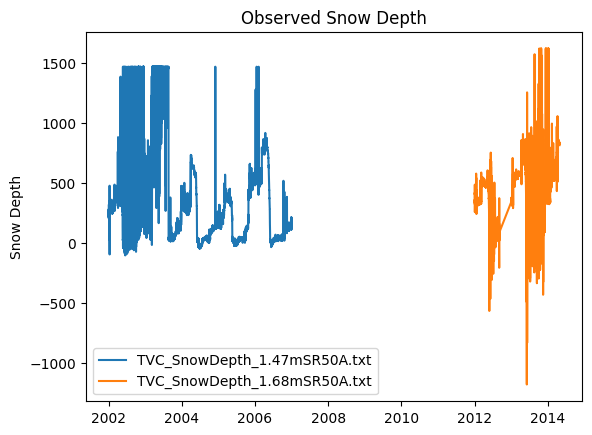

In [6]:
for data in observe:  
    plt.plot(observe[data]["time"], observe[data]["obs_depth"], label=f"{data}")
#plt.plot(obs2["time"], obs2["obs_depth"])
plt.ylabel("Snow Depth")
plt.title("Observed Snow Depth")
plt.legend()
plt.show()

Seems like the 1.68 data has negative values for some reason. Both datasets also max out at their respective sensor location, so 1.68 and 1.47.

## Combining data

first we check the units of the data.

In [7]:
var_snowd

<xarray.DataArray 'SNOW_DEPTH' (time: 7300, lndgrid: 1)> Size: 29kB
[7300 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      snow height of snow covered area
    units:          m
    cell_methods:   time: mean
    landunit_mask:  unknown

## Insert any conversions or other data manipulation

Its in meters so I'm going to change the observational data to meters to match. For now, I'll also be removing any negative values.

In [8]:
obs_clean = {}
for n in observe:
    observe[n]["obs_depth"] = observe[n]["obs_depth"]/1000
    #obs1_cleaned = obs1[obs1["obs_depth"] >= 0]
    observe[n] = observe[n][observe[n]["obs_depth"] >= 0]
    observe[n]["time"] = pd.to_datetime(observe[n]["time"])
    obs_clean.update({f"{n}":observe[n]})
    

for x in obs_clean:
  print(obs_clean[x]) 


                           time  obs_depth
0     2002-01-01 07:30:00+00:00      0.258
1     2002-01-01 08:00:00+00:00      0.256
2     2002-01-01 08:30:00+00:00      0.252
3     2002-01-01 09:00:00+00:00      0.250
4     2002-01-01 09:30:00+00:00      0.254
...                         ...        ...
87633 2007-01-01 05:00:00+00:00      0.155
87634 2007-01-01 05:30:00+00:00      0.157
87635 2007-01-01 06:00:00+00:00      0.158
87636 2007-01-01 06:30:00+00:00      0.165
87637 2007-01-01 07:00:00+00:00      0.169

[81810 rows x 2 columns]
                           time  obs_depth
0     2012-01-01 07:30:00+00:00      0.345
1     2012-01-01 08:00:00+00:00      0.346
2     2012-01-01 08:30:00+00:00      0.345
3     2012-01-01 09:00:00+00:00      0.345
4     2012-01-01 09:30:00+00:00      0.347
...                         ...        ...
34887 2014-04-26 16:00:00+00:00      0.818
34888 2014-04-26 16:30:00+00:00      0.815
34889 2014-04-26 17:00:00+00:00      0.818
34890 2014-04-26 17:30:00+00

plot to check

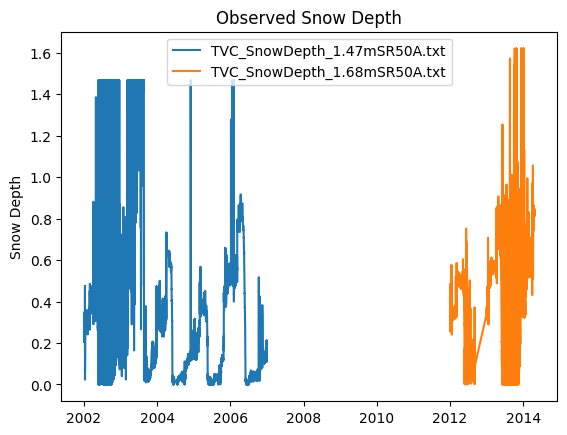

In [9]:
for data in obs_clean:  
    plt.plot(obs_clean[data]["time"], obs_clean[data]["obs_depth"], label=f"{data}")
plt.ylabel("Snow Depth")
plt.title("Observed Snow Depth")
plt.legend()
plt.show()

looks good so let's plot all the data

In [10]:
sim = var_snowd.copy()
sim['time'] = sim.indexes['time'].to_datetimeindex()


/tmp/ipykernel_127332/891719653.py:2: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  sim['time'] = sim.indexes['time'].to_datetimeindex()
/tmp/ipykernel_127332/891719653.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  sim['time'] = sim.indexes['time'].to_datetimeindex()


In [11]:
obs_concat = pd.concat(obs_clean, ignore_index=True, sort=True)
print(obs_concat)

        obs_depth                      time
0           0.258 2002-01-01 07:30:00+00:00
1           0.256 2002-01-01 08:00:00+00:00
2           0.252 2002-01-01 08:30:00+00:00
3           0.250 2002-01-01 09:00:00+00:00
4           0.254 2002-01-01 09:30:00+00:00
...           ...                       ...
113174      0.818 2014-04-26 16:00:00+00:00
113175      0.815 2014-04-26 16:30:00+00:00
113176      0.818 2014-04-26 17:00:00+00:00
113177      0.816 2014-04-26 17:30:00+00:00
113178      0.814 2014-04-26 18:00:00+00:00

[113179 rows x 2 columns]


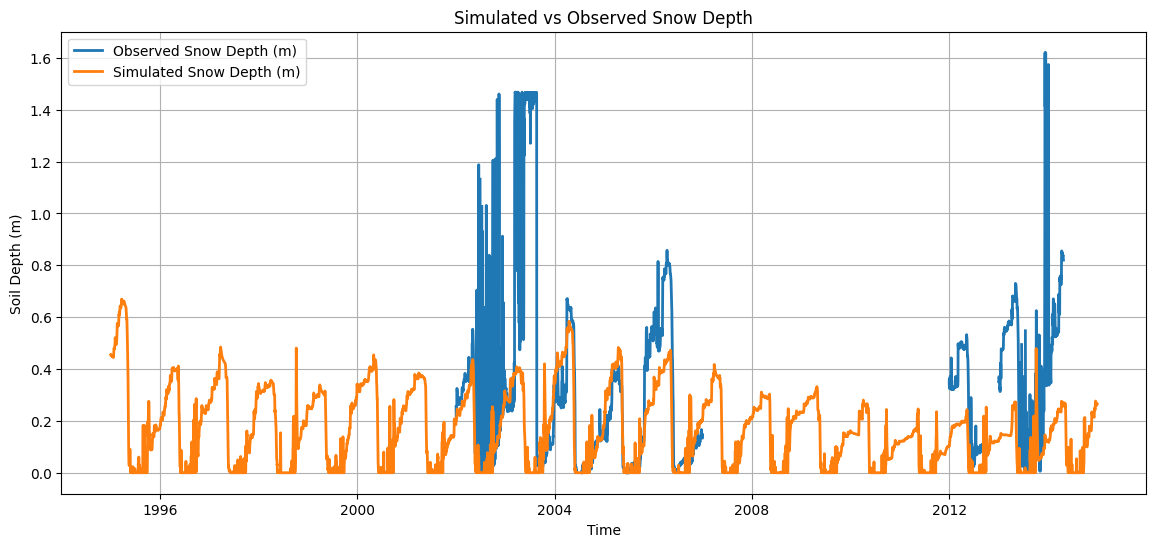

In [ ]:

# Convert pandas → xarray
obs = obs_concat.set_index("time").to_xarray()

# Resample observational data to daily frequency
obs_daily = obs.resample(time="1D").mean()


plt.figure(figsize=(14,6))

# Observed (daily)
plt.plot(
    obs_daily["time"].values,
    obs_daily["obs_depth"].values,
    label="Observed Snow Depth (m)",
    linewidth=2
)

# Simulated
plt.plot(
    sim["time"].values,
    sim.values,
    label="Simulated Snow Depth (m)",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Soil Depth (m)")
plt.title("Simulated vs Observed Snow Depth")
plt.grid(True)
plt.legend()
#plt.savefig("0_final_images/snow_depth.png")
plt.show()